# 检查得到的结果

In [30]:
suppressMessages(library(dplyr))
suppressMessages(library(magrittr))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(tibble))

In [5]:
F1 <- fread("./output/MS//Fragpipe_output//2024-10-31-4/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561/protein.tsv")

In [12]:
head(F1)
nrow(F1)
colnames(F1)
filter(F1,Length<=150) %>% nrow()
filter(F1,Length<=150 & `Unique Peptides`>0) %>% nrow()

Protein,Protein ID,Entry Name,Gene,Length,Organism,Protein Description,Protein Existence,Coverage,Protein Probability,⋯,Razor Peptides,Total Spectral Count,Unique Spectral Count,Razor Spectral Count,Total Intensity,Unique Intensity,Razor Intensity,Razor Assigned Modifications,Razor Observed Modifications,Indistinguishable Proteins
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
contam_sp|P00441|SODC_HUMAN,P00441,SODC_HUMAN,SOD1,154,Homo sapiens,Superoxide dismutase [Cu-Zn],1:Experimental evidence at protein level,21.43,1,⋯,1,1,1,1,15875.52,15875.52,15875.52,"21C(57.0215),21C(57.0215)",NA,
contam_sp|P00760|TRY1_BOVIN,P00760,TRY1_BOVIN,PRSS1,246,Bos taurus,Serine protease 1,1:Experimental evidence at protein level,31.30,1,⋯,5,12,12,12,290423.28,290423.28,290423.28,"13C(57.0215),3C(57.0215),17M(15.9949),9C(57.0215)",NA,
contam_sp|P00761|TRYP_PIG,P00761,TRYP_PIG,,231,Sus scrofa,Trypsin,1:Experimental evidence at protein level,8.66,1,⋯,3,2,2,2,101274.38,101274.38,101274.38,,NA,
contam_sp|P00883|ALDOA_RABIT,P00883,ALDOA_RABIT,ALDOA,364,Oryctolagus cuniculus,Fructose-bisphosphate aldolase A,1:Experimental evidence at protein level,51.37,1,⋯,0,70,0,0,2956966.20,0.00,0.00,,NA,
contam_sp|P04264|K2C1_HUMAN,P04264,K2C1_HUMAN,KRT1,644,Homo sapiens,"Keratin, type II cytoskeletal 1",1:Experimental evidence at protein level,7.30,1,⋯,4,3,3,3,47831.53,47831.53,47831.53,N-term(42.0106),NA,
contam_sp|P06732|KCRM_HUMAN,P06732,KCRM_HUMAN,CKM,381,Homo sapiens,Creatine kinase M-type,1:Experimental evidence at protein level,8.40,1,⋯,1,2,1,1,38267.08,17905.69,17905.69,,NA,


[1] 750

[1] "Protein"                      "Protein ID"                  
 [3] "Entry Name"                   "Gene"                        
 [5] "Length"                       "Organism"                    
 [7] "Protein Description"          "Protein Existence"           
 [9] "Coverage"                     "Protein Probability"         
[11] "Top Peptide Probability"      "Total Peptides"              
[13] "Unique Peptides"              "Razor Peptides"              
[15] "Total Spectral Count"         "Unique Spectral Count"       
[17] "Razor Spectral Count"         "Total Intensity"             
[19] "Unique Intensity"             "Razor Intensity"             
[21] "Razor Assigned Modifications" "Razor Observed Modifications"
[23] "Indistinguishable Proteins"

[1] 58

[1] 48

In [35]:
combined <- fread("./output/MS//Fragpipe_output/2024-10-31-4/combined_protein.tsv",data.table = F)

In [36]:
head(combined)
nrow(combined)
colnames(combined)
filter(combined,`Protein Length` <=150) %>% nrow()
filter(combined,`Protein Length`<=150 & `Combined Unique Spectral Count`>0) %>% nrow()

,Protein,Protein ID,Entry Name,Gene,Protein Length,Organism,Protein Existence,Description,Protein Probability,Top Peptide Probability,⋯,CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 MaxLFQ Intensity,Indistinguishable Proteins
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,contam_sp|P00441|SODC_HUMAN,P00441,SODC_HUMAN,SOD1,154,Homo sapiens,1:Experimental evidence at protein level,Superoxide dismutase [Cu-Zn],1,0.999,⋯,43803.740,44365.790,55379.30,42144.87,16642.55,0.00,23686.76,24440.146,30617.395,
2,contam_sp|P00760|TRY1_BOVIN,P00760,TRY1_BOVIN,PRSS1,246,Bos taurus,1:Experimental evidence at protein level,Serine protease 1,1,0.999,⋯,6033854.000,8987847.000,7024537.50,823189.75,3663131.50,704133.00,1463181.00,2883424.500,2114701.500,
3,contam_sp|P00761|TRYP_PIG,P00761,TRYP_PIG,,231,Sus scrofa,1:Experimental evidence at protein level,Trypsin,1,0.999,⋯,267549.120,127103.510,230643.86,223484.55,55994.16,424384.84,152901.23,90811.805,133270.890,
4,contam_sp|P00883|ALDOA_RABIT,P00883,ALDOA_RABIT,ALDOA,364,Oryctolagus cuniculus,1:Experimental evidence at protein level,Fructose-bisphosphate aldolase A,1,0.999,⋯,0.000,38185.914,10595.08,0.00,0.00,0.00,0.00,20981.963,7019.964,
5,contam_sp|P02768|ALBU_HUMAN,P02768,ALBU_HUMAN,ALB,609,Homo sapiens,1:Experimental evidence at protein level,Albumin,1,0.999,⋯,57974.117,9025.773,8304.03,0.00,0.00,95489.30,26348.36,9025.773,4851.792,
6,contam_sp|P04264|K2C1_HUMAN,P04264,K2C1_HUMAN,KRT1,644,Homo sapiens,1:Experimental evidence at protein level,"Keratin, type II cytoskeletal 1",1,0.999,⋯,8767.583,109031.980,454386.40,165320.50,22577.59,89030.89,19283.29,24580.525,58434.953,


[1] 2468

[1] "Protein"                                                                       
 [2] "Protein ID"                                                                    
 [3] "Entry Name"                                                                    
 [4] "Gene"                                                                          
 [5] "Protein Length"                                                                
 [6] "Organism"                                                                      
 [7] "Protein Existence"                                                             
 [8] "Description"                                                                   
 [9] "Protein Probability"                                                           
[10] "Top Peptide Probability"                                                       
[11] "Combined Total Peptides"                                                       
[12] "Combined Spectral Count"                                                       
[13] "Combined Unique Spectral Count"                                                
[14] "Combined Total Spectral Count"                                                 
[15] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Spectral Count"       
[16] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Spectral Count"       
[17] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Spectral Count"       
[18] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Spectral Count"       
[19] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Spectral Count"       
[20] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Spectral Count"       
[21] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Unique Spectral Count"
[22] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Unique Spectral Count"
[23] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Unique Spectral Count"
[24] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Unique Spectral Count"
[25] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Unique Spectral Count"
[26] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Unique Spectral Count"
[27] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Total Spectral Count" 
[28] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Total Spectral Count" 
[29] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Total Spectral Count" 
[30] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Total Spectral Count" 
[31] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Total Spectral Count" 
[32] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Total Spectral Count" 
[33] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Intensity"            
[34] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Intensity"            
[35] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Intensity"            
[36] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Intensity"            
[37] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Intensity"            
[38] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Intensity"            
[39] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 MaxLFQ Intensity"     
[40] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 MaxLFQ Intensity"     
[41] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 MaxLFQ Intensity"     
[42] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 MaxLFQ Intensity"     
[43] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 MaxLFQ Intensity"     
[44] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 MaxLFQ Intensity"     
[45] "Indistinguishable Proteins"

[1] 230

[1] 205

In [37]:
table(combined$Organism)
colnames(combined)


           Bos taurus          Homo sapiens          Mus musculus 
                    1                    12                  2453 
Oryctolagus cuniculus            Sus scrofa 
                    1                     1 

[1] "Protein"                                                                       
 [2] "Protein ID"                                                                    
 [3] "Entry Name"                                                                    
 [4] "Gene"                                                                          
 [5] "Protein Length"                                                                
 [6] "Organism"                                                                      
 [7] "Protein Existence"                                                             
 [8] "Description"                                                                   
 [9] "Protein Probability"                                                           
[10] "Top Peptide Probability"                                                       
[11] "Combined Total Peptides"                                                       
[12] "Combined Spectral Count"                                                       
[13] "Combined Unique Spectral Count"                                                
[14] "Combined Total Spectral Count"                                                 
[15] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Spectral Count"       
[16] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Spectral Count"       
[17] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Spectral Count"       
[18] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Spectral Count"       
[19] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Spectral Count"       
[20] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Spectral Count"       
[21] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Unique Spectral Count"
[22] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Unique Spectral Count"
[23] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Unique Spectral Count"
[24] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Unique Spectral Count"
[25] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Unique Spectral Count"
[26] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Unique Spectral Count"
[27] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Total Spectral Count" 
[28] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Total Spectral Count" 
[29] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Total Spectral Count" 
[30] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Total Spectral Count" 
[31] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Total Spectral Count" 
[32] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Total Spectral Count" 
[33] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 Intensity"            
[34] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 Intensity"            
[35] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 Intensity"            
[36] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 Intensity"            
[37] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 Intensity"            
[38] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 Intensity"            
[39] "CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 MaxLFQ Intensity"     
[40] "CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 MaxLFQ Intensity"     
[41] "CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 MaxLFQ Intensity"     
[42] "CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 MaxLFQ Intensity"     
[43] "CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 MaxLFQ Intensity"     
[44] "CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 MaxLFQ Intensity"     
[45] "Indistinguishable Proteins"

In [38]:
combined %>% select("Protein",colnames(combined)[grep("MaxLFQ Intensity",colnames(combined))]) -> MaxLFQ_Intensity

In [39]:
head(MaxLFQ_Intensity) %>% print()

                       Protein
1  contam_sp|P00441|SODC_HUMAN
2  contam_sp|P00760|TRY1_BOVIN
3    contam_sp|P00761|TRYP_PIG
4 contam_sp|P00883|ALDOA_RABIT
5  contam_sp|P02768|ALBU_HUMAN
6  contam_sp|P04264|K2C1_HUMAN
  CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 MaxLFQ Intensity
1                                                                  42144.87
2                                                                 823189.75
3                                                                 223484.55
4                                                                      0.00
5                                                                      0.00
6                                                                 165320.50
  CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 MaxLFQ Intensity
1                                                                  16642.55
2                                                                3663131.50
3                      

In [138]:
# 加载必要的包
library(ggplot2)
library(reshape2)
library(pheatmap)

# 假设你的数据框名为MaxLFQ_Intensity，行名为蛋白质，列名为样本
# 对数据进行归一化（例如，将每个样本的值除以该样本的总和）
MaxLFQ_Intensity %>% column_to_rownames("Protein") -> MaxLFQ_Intensity_1
nrow(MaxLFQ_Intensity_1)
# MaxLFQ_Intensity_1+0.001 -> MaxLFQ_Intensity_2
rowSums(MaxLFQ_Intensity_1)!=0 -> tmp
MaxLFQ_Intensity_1[rowSums(MaxLFQ_Intensity_1)!=0,] -> MaxLFQ_Intensity_2
nrow(MaxLFQ_Intensity_2)
tail(MaxLFQ_Intensity_2)
colnames(MaxLFQ_Intensity_2)  <- c("F1","F3","P1","P3","S1","S3")
normalized_data <- as.data.frame(t(apply(MaxLFQ_Intensity_2, 1, function(x) (x -mean(x)) / sd(x))))                     

[1] 2468

[1] 2336

,CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558 MaxLFQ Intensity
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sp|Q9Z2W0|DNPEP_MOUSE,0.00,28363.807,0,28986.030,0.000,14675.925
sp|Q9Z2W9|GRIA3_MOUSE,0.00,10085.321,0,2959.962,24378.566,7279.799
sp|Q9Z2X1-2|HNRPF_MOUSE,56524.28,52028.504,0,42524.547,36389.383,91525.664
sp|Q9Z2Y3|HOME1_MOUSE,0.00,32283.914,0,10094.000,45764.280,50290.004
sp|Q9Z2Y8|PLPHP_MOUSE,64100.87,23626.406,0,26958.600,14433.501,37728.074
sp|S4R1M9|OSB10_MOUSE,0.00,8817.338,0,11538.236,6694.573,4692.185


In [139]:
sum(is.na(normalized_data))

[1] 0

In [140]:
colnames(normalized_data)

[1] "F1" "F3" "P1" "P3" "S1" "S3"

In [143]:
normalized_data %>% head()

,F1,F3,P1,P3,S1,S3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
contam_sp|P00441|SODC_HUMAN,1.3616660,-0.4448049,-1.6236896,0.0541755,0.1075420,0.54511098
contam_sp|P00760|TRY1_BOVIN,-0.9529327,1.4660384,-1.0543414,-0.4078087,0.8019090,0.14713548
contam_sp|P00761|TRYP_PIG,0.3269640,-0.9365143,1.8424726,-0.2054874,-0.6738643,-0.35357056
contam_sp|P00883|ALDOA_RABIT,-0.5508996,-0.5508996,-0.5508996,-0.5508996,1.9258488,0.27774951
contam_sp|P02768|ALBU_HUMAN,-0.6112104,-0.6112104,1.9690771,0.1007683,-0.3673182,-0.48010647
contam_sp|P04264|K2C1_HUMAN,1.7946103,-0.7139898,0.4538773,-0.7718847,-0.6787897,-0.08382342


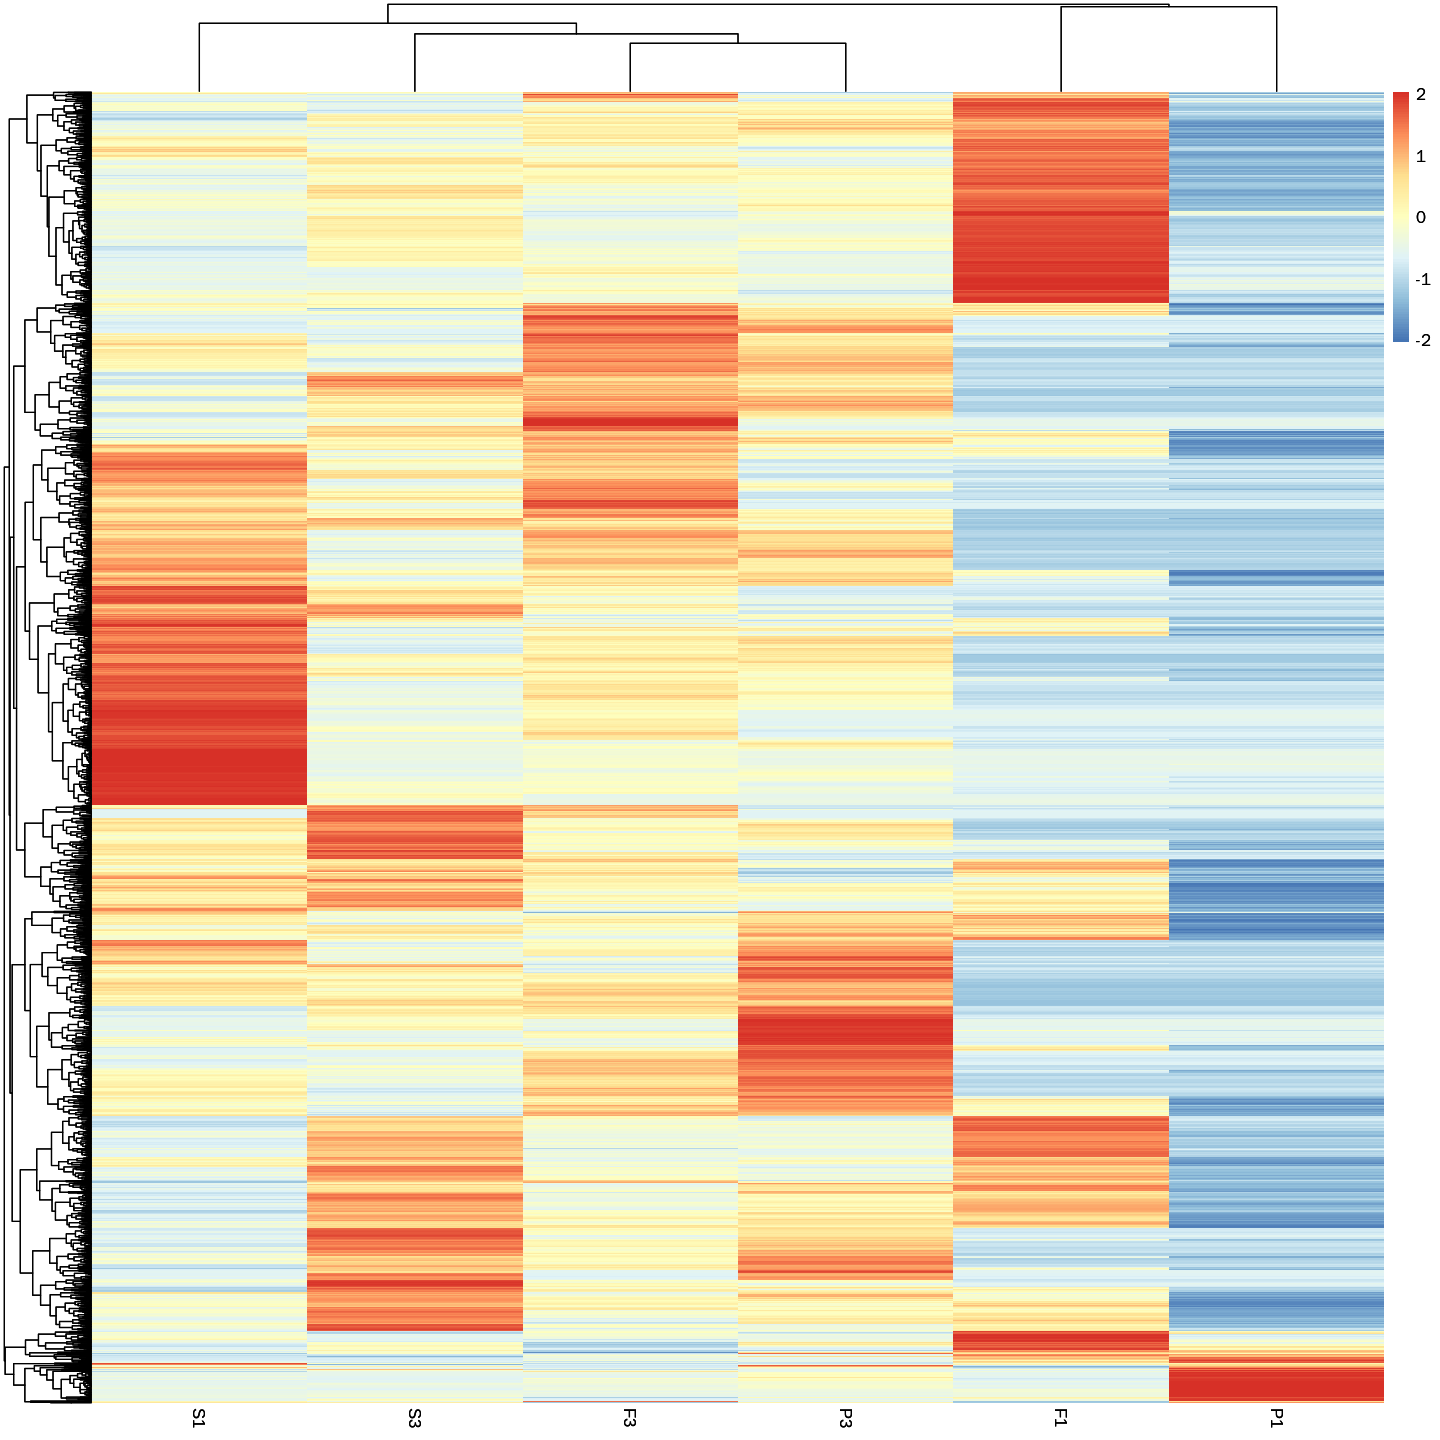

In [145]:
options(
repr.plot.width=12,
repr.plot.height=12
)
library(viridis)
# 绘制热图
ph <- pheatmap(normalized_data, show_rownames = FALSE)
ph
ggsave(ph,filename = "output/MS/visual/Less_3k_ph.pdf",width = 10,height = 10)

In [57]:
rowSums(MaxLFQ_Intensity_3)

contam_sp|P00441|SODC_HUMAN  contam_sp|P00760|TRY1_BOVIN 
                  137531.727                 11651761.256 
   contam_sp|P00761|TRYP_PIG contam_sp|P00883|ALDOA_RABIT 
                 1080847.477                    28001.933 
 contam_sp|P02768|ALBU_HUMAN  contam_sp|P04264|K2C1_HUMAN 
                  135715.239                   379227.753 
 contam_sp|P06732|KCRM_HUMAN contam_sp|P0DTE7|AMY1B_HUMAN 
                  287902.920                   329939.173 
contam_sp|P12081|HARS1_HUMAN contam_sp|P13645|K1C10_HUMAN 
                   41359.664                    51582.901 
 contam_sp|P35527|K1C9_HUMAN  contam_sp|P35908|K22E_HUMAN 
                  500883.540                   143200.700 
 contam_sp|P61626|LYSC_HUMAN  contam_sp|P63279|UBC9_HUMAN 
                  312939.099                    33067.619 
contam_sp|Q15843|NEDD8_HUMAN      sp|A2A690-2|TANC2_MOUSE 
                   40763.784                        0.006 
     sp|A2AG50-2|MA7D2_MOUSE      sp|A2AGT5-2|CKAP5_MOUSE 
                  197335.955                        0.006 
     sp|A2AJI0-2|MA7D1_MOUSE      sp|A2ALS5-2|RPGP1_MOUSE 
                  198574.088                   281853.138 
     sp|A2ALU4-2|SHRM2_MOUSE       sp|A2AN08-2|UBR4_MOUSE 
                   55177.836                        0.006 
     sp|A2AP18-2|PLCH2_MOUSE      sp|A2APX8-2|SCN1A_MOUSE 
                  550113.098                    19744.922 
        sp|A2AQ07|TBB1_MOUSE        sp|A2AQ25-2|SKT_MOUSE 
                  617605.120                    39329.806 
       sp|A2ARS0|ANR63_MOUSE         sp|A2AS89|GDAH_MOUSE 
                   89826.582                   129855.582 
     sp|A2AWA9-2|RBGP1_MOUSE        sp|A2BDX3|MOCS3_MOUSE 
                   43235.621                   355023.699 
    sp|A2CG49-10|KALRN_MOUSE        sp|A2RT62|FXL16_MOUSE 
                       0.006                   272616.168 
       sp|A3KGK3|FR1L4_MOUSE      sp|B0V2N1-2|PTPRS_MOUSE 
                   11219.943                    68474.478 
       sp|B1AWN6|SCN2A_MOUSE        sp|B1AXH1|NHSL2_MOUSE 
                   46112.358                    30291.683 
     sp|B1AZP2-2|DLGP4_MOUSE        sp|B2RSH2|GNAI1_MOUSE 
                  128072.332                   699995.706 
     sp|B2RUJ5-2|APBA1_MOUSE      sp|B2RXC1-2|TPC11_MOUSE 
                   28971.188                    28698.264 
       sp|B2RY56|RBM25_MOUSE      sp|B9EJA2-2|CTTB2_MOUSE 
                   25747.701                    51171.876 
       sp|B9EKR1|PTPRZ_MOUSE        sp|C0HKE1|H2A1B_MOUSE 
                  607155.732                  2900081.496 
     sp|D3YUB6-3|BTBD8_MOUSE        sp|D3YVF0|AKAP5_MOUSE 
                   64241.081                   550031.638 
      sp|D3YXJ0-2|DGKH_MOUSE        sp|D3YXK2|SAFB1_MOUSE 
                   42502.640                   125890.104 
     sp|D3YZI9-2|PGBD5_MOUSE        sp|D3YZP9|CCDC6_MOUSE 
                       0.006                   223362.774 
       sp|D3YZU1|SHAN1_MOUSE        sp|D3Z4S3|PTRD1_MOUSE 
                  198319.889                    70167.564 
        sp|D3Z6Q9|BIN2_MOUSE         sp|D3Z7P3|GLSK_MOUSE 
                  106147.896                   941094.502 
       sp|E9PUL5|PRRT2_MOUSE         sp|E9PUQ8|DGKD_MOUSE 
                 1425637.996                    36458.926 
        sp|E9PVA8|GCN1_MOUSE        sp|E9Q3L2|PI4KA_MOUSE 
                  164003.689                    57509.322 
        sp|E9Q401|RYR2_MOUSE        sp|E9Q4Z2|ACACB_MOUSE 
                   47868.941                        0.006 
       sp|E9Q6B2|CC85C_MOUSE      sp|E9Q7M2-2|T22D2_MOUSE 
                   33967.672                   132107.384 
      sp|E9Q912-3|GDS1_MOUSE        sp|F6SEU4|SYGP1_MOUSE 
                  492638.427                   305251.156 
         sp|F6ZDS4|TPR_MOUSE        sp|F8VPU2|FARP1_MOUSE 
                   76502.673                   302088.260 
        sp|G3UW82|MYH2_MOUSE         sp|G3X982|AOXC_MOUSE 
                       0.006                   1

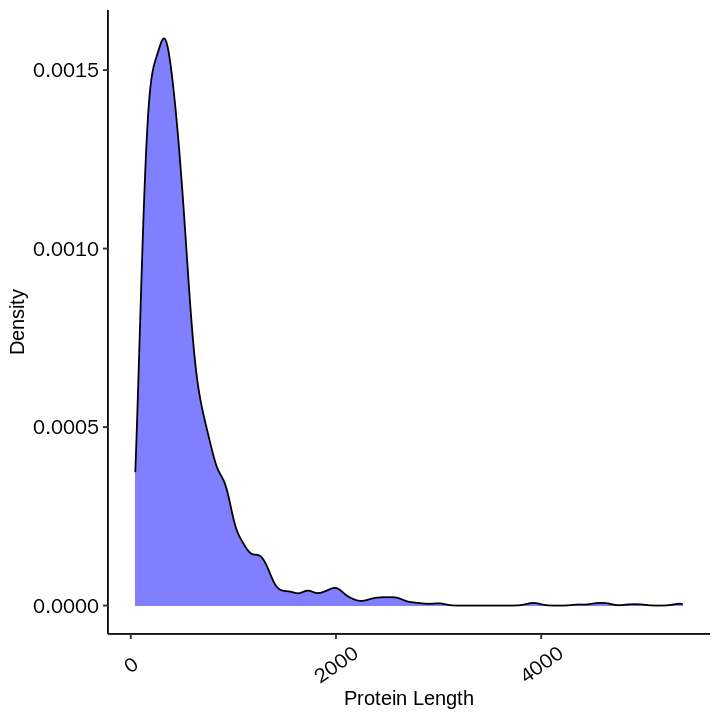

In [160]:
library(ggpubr)
options(
repr.plot.width=6,
repr.plot.height=6
)
ggplot(combined, aes(x=`Protein Length`)) +
  geom_density(fill="blue", alpha=0.5) +
  xlab("Protein Length") +
  ylab("Density")+theme_pubr()+
theme(axis.text.x = element_text(angle=35,vjust = 0.5,hjust = 0.5))

In [65]:
combined_1 <- fread("./output/MS//Fragpipe_output/2024-11-01-1/combined_protein.tsv",data.table = F)

In [66]:
head(combined_1)
nrow(combined_1)
colnames(combined_1)
filter(combined_1,`Protein Length` <=150) %>% nrow()
filter(combined_1,`Protein Length`<=150 & `Combined Unique Spectral Count`>0) %>% nrow()

,Protein,Protein ID,Entry Name,Gene,Protein Length,Organism,Protein Existence,Description,Protein Probability,Top Peptide Probability,⋯,CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2_52_1_3562 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_F4_Slot2_54_1_3564 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P2_Slot1_41_1_3552 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 MaxLFQ Intensity,Indistinguishable Proteins
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,contam_sp|P00760|TRY1_BOVIN,P00760,TRY1_BOVIN,PRSS1,246,Bos taurus,1:Experimental evidence at protein level,Serine protease 1,1.0000,0.9990,⋯,59239248.0,34939152.0,28881528.00,18132828.0,22211958.0,25286616.000,27628772.0,27574572.00,26115582.000,
2,contam_sp|P00883|ALDOA_RABIT,P00883,ALDOA_RABIT,ALDOA,364,Oryctolagus cuniculus,1:Experimental evidence at protein level,Fructose-bisphosphate aldolase A,1.0000,0.9990,⋯,162394.1,142875.0,112212.89,416779.7,334649.6,4907.788,470298.4,92507.52,5604.074,
3,contam_sp|P01112|RASH_HUMAN,P01112,RASH_HUMAN,HRAS,189,Homo sapiens,1:Experimental evidence at protein level,GTPase HRas,1.0000,0.9990,⋯,922804.4,452209.1,129790.86,354567.4,416134.8,204871.810,223008.1,139716.42,93435.195,sp|Q61411|RASH_MOUSE
4,contam_sp|P02769|ALBU_BOVIN,P02769,ALBU_BOVIN,ALB,607,Bos taurus,1:Experimental evidence at protein level,Albumin,0.9618,0.9963,⋯,0.0,0.0,96647.97,0.0,0.0,0.000,0.0,0.00,0.000,
5,contam_sp|P04264|K2C1_HUMAN,P04264,K2C1_HUMAN,KRT1,644,Homo sapiens,1:Experimental evidence at protein level,"Keratin, type II cytoskeletal 1",1.0000,0.9990,⋯,879718.8,1202110.8,1309875.10,434538.2,622215.8,286303.160,290323.5,376274.88,468070.060,
6,contam_sp|P06732|KCRM_HUMAN,P06732,KCRM_HUMAN,CKM,381,Homo sapiens,1:Experimental evidence at protein level,Creatine kinase M-type,1.0000,0.9990,⋯,240589.9,239486.6,218025.81,192533.9,305150.2,50304.910,103961.4,103924.66,110246.780,


[1] 5659

[1] "Protein"                                                                       
 [2] "Protein ID"                                                                    
 [3] "Entry Name"                                                                    
 [4] "Gene"                                                                          
 [5] "Protein Length"                                                                
 [6] "Organism"                                                                      
 [7] "Protein Existence"                                                             
 [8] "Description"                                                                   
 [9] "Protein Probability"                                                           
[10] "Top Peptide Probability"                                                       
[11] "Combined Total Peptides"                                                       
[12] "Combined Spectral Count"                                                       
[13] "Combined Unique Spectral Count"                                                
[14] "Combined Total Spectral Count"                                                 
[15] "CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2_52_1_3562 Spectral Count"       
[16] "CAD20241022licq_BSEP_PreExp_DDA_60min_F4_Slot2_54_1_3564 Spectral Count"       
[17] "CAD20241022licq_BSEP_PreExp_DDA_60min_P2_Slot1_41_1_3552 Spectral Count"       
[18] "CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 Spectral Count"       
[19] "CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 Spectral Count"       
[20] "CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 Spectral Count"       
[21] "CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2_52_1_3562 Unique Spectral Count"
[22] "CAD20241022licq_BSEP_PreExp_DDA_60min_F4_Slot2_54_1_3564 Unique Spectral Count"
[23] "CAD20241022licq_BSEP_PreExp_DDA_60min_P2_Slot1_41_1_3552 Unique Spectral Count"
[24] "CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 Unique Spectral Count"
[25] "CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 Unique Spectral Count"
[26] "CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 Unique Spectral Count"
[27] "CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2_52_1_3562 Total Spectral Count" 
[28] "CAD20241022licq_BSEP_PreExp_DDA_60min_F4_Slot2_54_1_3564 Total Spectral Count" 
[29] "CAD20241022licq_BSEP_PreExp_DDA_60min_P2_Slot1_41_1_3552 Total Spectral Count" 
[30] "CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 Total Spectral Count" 
[31] "CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 Total Spectral Count" 
[32] "CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 Total Spectral Count" 
[33] "CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2_52_1_3562 Intensity"            
[34] "CAD20241022licq_BSEP_PreExp_DDA_60min_F4_Slot2_54_1_3564 Intensity"            
[35] "CAD20241022licq_BSEP_PreExp_DDA_60min_P2_Slot1_41_1_3552 Intensity"            
[36] "CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 Intensity"            
[37] "CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 Intensity"            
[38] "CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 Intensity"            
[39] "CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2_52_1_3562 MaxLFQ Intensity"     
[40] "CAD20241022licq_BSEP_PreExp_DDA_60min_F4_Slot2_54_1_3564 MaxLFQ Intensity"     
[41] "CAD20241022licq_BSEP_PreExp_DDA_60min_P2_Slot1_41_1_3552 MaxLFQ Intensity"     
[42] "CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 MaxLFQ Intensity"     
[43] "CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 MaxLFQ Intensity"     
[44] "CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 MaxLFQ Intensity"     
[45] "Indistinguishable Proteins"

[1] 466

[1] 425

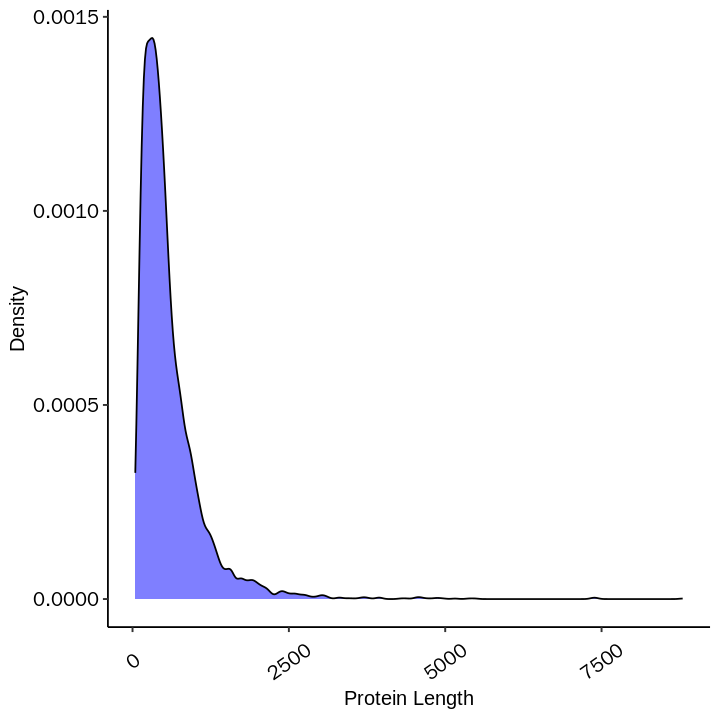

In [161]:
library(ggpubr)
options(
repr.plot.width=6,
repr.plot.height=6
)
ggplot(combined_1, aes(x=`Protein Length`)) +
  geom_density(fill="blue", alpha=0.5) +
  xlab("Protein Length") +
  ylab("Density")+theme_pubr()+
theme(axis.text.x = element_text(angle=35,vjust = 0.5,hjust = 0.5))

[1] 5659

[1] 5568

,CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2_52_1_3562 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_F4_Slot2_54_1_3564 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P2_Slot1_41_1_3552 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_P4_Slot1_43_1_3554 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S2_Slot1_45_1_3557 MaxLFQ Intensity,CAD20241022licq_BSEP_PreExp_DDA_60min_S4_Slot1_54_1_3559 MaxLFQ Intensity
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sp|Q9Z307|KCJ16_MOUSE,30119.19,58248.15,11825.99,7419.236,0.00,0.00
sp|Q9Z315|SNUT1_MOUSE,52657.60,64210.11,81594.83,64865.957,151122.92,151457.53
sp|Q9Z321|TOP3B_MOUSE,93989.26,102398.12,83640.94,86738.086,65032.52,66731.62
sp|Q9Z351-12|KCNQ2_MOUSE,72506.79,68262.06,51516.11,56053.855,120414.20,66670.11
sp|S4R1M9|OSB10_MOUSE,58175.55,55003.09,51167.35,52849.930,35521.68,22660.15
sp|S4R2P9-2|NAC3_MOUSE,46531.69,56767.74,77195.83,48546.790,21608.27,28427.29


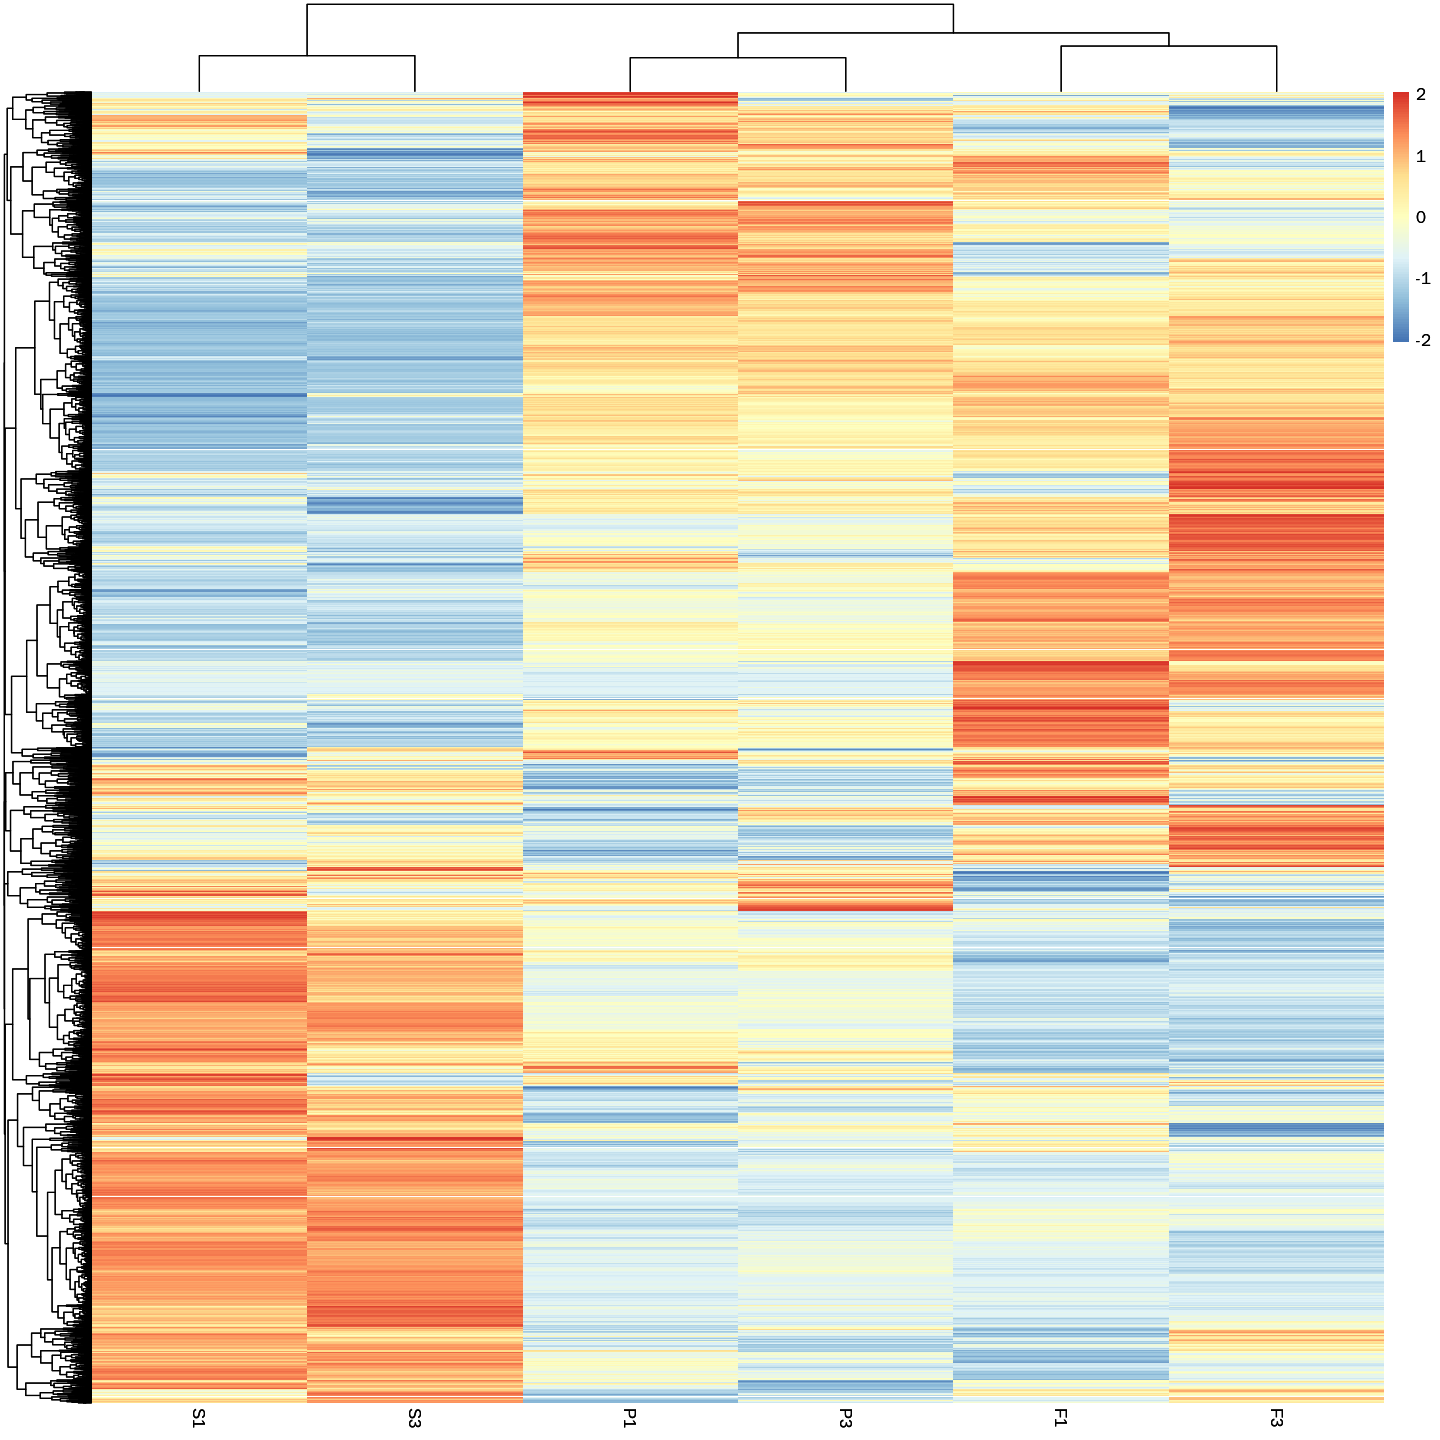

In [163]:
combined_1 %>% select("Protein",colnames(combined_1)[grep("MaxLFQ Intensity",colnames(combined_1))]) -> MaxLFQ_Intensity
# 加载必要的包
library(ggplot2)
library(reshape2)
library(pheatmap)

# 假设你的数据框名为MaxLFQ_Intensity，行名为蛋白质，列名为样本
# 对数据进行归一化（例如，将每个样本的值除以该样本的总和）
MaxLFQ_Intensity %>% column_to_rownames("Protein") -> MaxLFQ_Intensity_1
nrow(MaxLFQ_Intensity_1)
# MaxLFQ_Intensity_1+0.001 -> MaxLFQ_Intensity_2
rowSums(MaxLFQ_Intensity_1)!=0 -> tmp
MaxLFQ_Intensity_1[rowSums(MaxLFQ_Intensity_1)!=0,] -> MaxLFQ_Intensity_2
nrow(MaxLFQ_Intensity_2)
tail(MaxLFQ_Intensity_2)
colnames(MaxLFQ_Intensity_2)  <- c("F1","F3","P1","P3","S1","S3")
normalized_data <- as.data.frame(t(apply(MaxLFQ_Intensity_2, 1, function(x) (x -mean(x)) / sd(x))))   
options(
repr.plot.width=12,
repr.plot.height=12
)
library(viridis)
# 绘制热图
ph <- pheatmap(normalized_data, show_rownames = FALSE)
ph
ggsave(ph,filename = "output/MS/visual/Less_3k_ph.pdf",width = 10,height = 10)

# 检查得到的结果-加上了ribo-seq的库

In [186]:
F1 <- fread("./output/MS//Fragpipe_output//2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561/protein.tsv",data.table = F)

In [196]:
df <- F1
head(df)
colnames(df)
nrow(df)
df %>% filter(Organism=="Mus musculus" | Organism=="") -> df_fil_spe
nrow(df_fil_spe)
df_fil_spe[!grepl("^rev",df_fil_spe$Protein),] -> df_fil_spe_decoy
nrow(df_fil_spe_decoy)
df_fil_spe_decoy -> df

,Protein,Protein ID,Entry Name,Gene,Length,Organism,Protein Description,Protein Existence,Coverage,Protein Probability,⋯,Razor Peptides,Total Spectral Count,Unique Spectral Count,Razor Spectral Count,Total Intensity,Unique Intensity,Razor Intensity,Razor Assigned Modifications,Razor Observed Modifications,Indistinguishable Proteins
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
1,ENSMUST00000005185.8+chr10:78261628-78263273,ENSMUST00000005185.8+chr10:78261628-78263273,ENSMUST00000005185.8+chr10:78261628-78263273,,97,,ENSMUST00000005185.8+chr10:78261628-78263273,,21.65,1,⋯,2,3,0,3,36196.88,0,36196.88,,NA,sp|Q62426|CYTB_MOUSE
2,ENSMUST00000034720.12-chr9:71391054-71393187,ENSMUST00000034720.12-chr9:71391054-71393187,ENSMUST00000034720.12-chr9:71391054-71393187,,84,,ENSMUST00000034720.12-chr9:71391054-71393187,,35.71,1,⋯,1,2,0,2,50646.38,0,50646.38,21C(57.0215),NA,
3,ENSMUST00000040154.10-chr5:115483901-115487009,ENSMUST00000040154.10-chr5:115483901-115487009,ENSMUST00000040154.10-chr5:115483901-115487009,,112,,ENSMUST00000040154.10-chr5:115483901-115487009,,41.96,1,⋯,3,27,0,27,922219.56,0,922219.56,,NA,"ENSMUST00000137766.2-chr5:115483901-115486761, sp|P43024|CX6A1_MOUSE"
4,ENSMUST00000078717.7+chr16:37703552-37703846,ENSMUST00000078717.7+chr16:37703552-37703846,ENSMUST00000078717.7+chr16:37703552-37703846,,97,,ENSMUST00000078717.7+chr16:37703552-37703846,,16.49,1,⋯,0,1,0,0,32193.55,0,0.00,,NA,
5,ENSMUST00000105367.8+chr10:79978410-79981379,ENSMUST00000105367.8+chr10:79978410-79981379,ENSMUST00000105367.8+chr10:79978410-79981379,,131,,ENSMUST00000105367.8+chr10:79978410-79981379,,52.67,1,⋯,5,22,0,22,1251448.80,0,1251448.80,,NA,
6,ENSMUST00000117133.2-chr6:146364826-146365087,ENSMUST00000117133.2-chr6:146364826-146365087,ENSMUST00000117133.2-chr6:146364826-146365087,,86,,ENSMUST00000117133.2-chr6:146364826-146365087,,13.95,1,⋯,0,1,0,0,32611.66,0,0.00,,NA,


[1] "Protein"                      "Protein ID"                  
 [3] "Entry Name"                   "Gene"                        
 [5] "Length"                       "Organism"                    
 [7] "Protein Description"          "Protein Existence"           
 [9] "Coverage"                     "Protein Probability"         
[11] "Top Peptide Probability"      "Total Peptides"              
[13] "Unique Peptides"              "Razor Peptides"              
[15] "Total Spectral Count"         "Unique Spectral Count"       
[17] "Razor Spectral Count"         "Total Intensity"             
[19] "Unique Intensity"             "Razor Intensity"             
[21] "Razor Assigned Modifications" "Razor Observed Modifications"
[23] "Indistinguishable Proteins"

[1] 773

[1] 764

[1] 764

In [219]:
nrow(df)
filter(df,Length<=150) -> df_sORFs
filter(df,Length<=150 & `Unique Peptides`>0) -> df_sORFs_unique
data.frame(
nrow(df),
nrow(df_sORFs),
length(grep("ENSMUST",df_sORFs$Protein)),
nrow(df_sORFs)-length(grep("ENSMUST",df_sORFs$Protein)),
nrow(df_sORFs_unique),
length(grep("ENSMUST",df_sORFs_unique$Protein)),
nrow(df_sORFs_unique)-length(grep("ENSMUST",df_sORFs_unique$Protein))
    )

[1] 764

nrow.df.,nrow.df_sORFs.,length.grep..ENSMUST...df_sORFs.Protein..,nrow.df_sORFs....length.grep..ENSMUST...df_sORFs.Protein..,nrow.df_sORFs_unique.,length.grep..ENSMUST...df_sORFs_unique.Protein..,nrow.df_sORFs_unique....length.grep..ENSMUST...df_sORFs_unique.Protein..
<int>,<int>,<int>,<int>,<int>,<int>,<int>
764,100,49,51,45,7,38


In [245]:
get_table <- function(path){
df <- fread(path,data.table = F)
df %>% filter(Organism=="Mus musculus" | Organism=="") -> df_fil_spe
df_fil_spe[!grepl("^rev",df_fil_spe$Protein),] -> df_fil_spe_decoy
df_fil_spe_decoy -> df
filter(df,Length<=150) -> df_sORFs
filter(df,`Unique Peptides`>0) -> df_unique
filter(df_unique,Length<=150) -> df_unique_sORFs
res <- data.frame(
nrow(df),
nrow(df_sORFs),
length(grep("ENSMUST",df_sORFs$Protein)),
nrow(df_sORFs)-length(grep("ENSMUST",df_sORFs$Protein)),
nrow(df_unique),
nrow(df_unique_sORFs),
length(grep("ENSMUST",df_unique_sORFs$Protein)),
nrow(df_unique_sORFs)-length(grep("ENSMUST",df_unique_sORFs$Protein))
    )
colnames(res) <- c("Total_proteins","Total_sProteins","Total_sProteins_unannotated_identified_by_ribo",
                  "Total_sProteins_annotated","Total_unique_proteins",
                   "Total_unique_proteins_sProteins",
                   "Total_unique_proteins_sProteins_identified_by_ribo",
                  "Total_unique_proteins_sProteins_annotated")
return(res)
}

In [246]:
get_table("./output/MS//Fragpipe_output//2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561/protein.tsv")

Total_proteins,Total_sProteins,Total_sProteins_unannotated_identified_by_ribo,Total_sProteins_annotated,Total_unique_proteins,Total_unique_proteins_sProteins,Total_unique_proteins_sProteins_identified_by_ribo,Total_unique_proteins_sProteins_annotated
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
764,100,49,51,484,45,7,38


In [247]:
# 设置搜索的路径
search_path <- "./output/MS/Fragpipe_output/2024-11-01-2/"

# 使用list.files查找所有名为"protein.tsv"的文件
protein_files <- list.files(search_path, pattern = "^protein.tsv", full.names = TRUE,recursive = T)

protein_files

[1] "./output/MS/Fragpipe_output/2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561/protein.tsv"
[2] "./output/MS/Fragpipe_output/2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_F3_Slot2_53_1_3563/protein.tsv"
[3] "./output/MS/Fragpipe_output/2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_P1_Slot1_40_1_3551/protein.tsv"
[4] "./output/MS/Fragpipe_output/2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_P3_Slot1_42_1_3553/protein.tsv"
[5] "./output/MS/Fragpipe_output/2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_S1_Slot1_44_1_3556/protein.tsv"
[6] "./output/MS/Fragpipe_output/2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_S3_Slot1_53_1_3558/protein.tsv"

In [248]:
# 设置搜索的路径
search_path <- "./output/MS/Fragpipe_output/2024-11-01-2/"
# 使用list.files查找所有名为"protein.tsv"的文件
protein_files <- list.files(search_path, pattern = "^protein.tsv", full.names = TRUE,recursive = T)
lapply(protein_files,get_table) %>% do.call(rbind,.) -> res_1
res_1$Sample <- c("F1", "F3", "P1", "P3", "S1", "S3")

In [249]:
# 设置搜索的路径
search_path <- "./output/MS/Fragpipe_output/2024-11-01-03/"
# 使用list.files查找所有名为"protein.tsv"的文件
protein_files <- list.files(search_path, pattern = "^protein.tsv", full.names = TRUE,recursive = T)
lapply(protein_files,get_table) %>% do.call(rbind,.) -> res_2
res_2$Sample <- c("F2", "F4", "P2", "P4", "S2", "S4")

In [250]:
rbind(res_1,res_2) -> res
res

Total_proteins,Total_sProteins,Total_sProteins_unannotated_identified_by_ribo,Total_sProteins_annotated,Total_unique_proteins,Total_unique_proteins_sProteins,Total_unique_proteins_sProteins_identified_by_ribo,Total_unique_proteins_sProteins_annotated,Sample
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
764,100,49,51,484,45,7,38,F1
1933,304,162,142,1337,143,32,111,F3
181,43,23,20,108,23,7,16,P1
1719,240,126,114,1210,116,29,87,P3
1646,241,127,114,1139,119,29,90,S1
1610,269,134,135,1118,132,28,104,S3
4988,670,373,297,3642,391,149,242,F2
5016,709,406,303,3630,397,152,245,F4
4612,652,354,298,3347,390,149,241,P2


In [251]:
write.xlsx(res,file = "./output/MS/stat/res.xlsx")

# 交集

In [253]:
library(VennDiagram)

载入需要的程辑包：grid

载入需要的程辑包：futile.logger


载入程辑包：‘VennDiagram’


The following object is masked from ‘package:ggpubr’:

    rotate




In [259]:
get_list <- function(path){
df <- fread(path,data.table = F)
df %>% filter(Organism=="Mus musculus" | Organism=="") -> df_fil_spe
df_fil_spe[!grepl("^rev",df_fil_spe$Protein),] -> df_fil_spe_decoy
df_fil_spe_decoy -> df
filter(df,Length<=150) -> df_sORFs
filter(df,`Unique Peptides`>0) -> df_unique
filter(df_unique,Length<=150) -> df_unique_sORFs
res <- list(
df,
df_sORFs,
df_sORFs[grepl("^ENSMUST",df_sORFs$Protein),],
df_sORFs[grepl("^sp",df_sORFs$Protein),],
df_unique,
df_unique_sORFs,
df_sORFs[grepl("^ENSMUST",df_unique_sORFs$Protein),],
df_sORFs[grepl("^sp",df_unique_sORFs$Protein),]
    )
return(res)
}

In [262]:
get_list("./output/MS//Fragpipe_output//2024-11-01-2//CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561/protein.tsv") -> tmp

In [298]:
# 设置搜索的路径
search_path <- "./output/MS/Fragpipe_output/2024-11-01-2/"
# 使用list.files查找所有名为"protein.tsv"的文件
protein_files <- list.files(search_path, pattern = "^protein.tsv", full.names = TRUE,recursive = T)
lapply(protein_files,get_list) -> list_1

In [307]:
plot_input <- list(F1=list_1[[1]][[1]]$`Protein`,
     F3=list_1[[2]][[1]]$`Protein`,
     P1=list_1[[3]][[1]]$`Protein`,
     P3=list_1[[4]][[1]]$`Protein`,
     S1=list_1[[5]][[1]]$`Protein`,
     S3=list_1[[6]][[1]]$`Protein`)

,F1,F3,P1,P3,S1,S3
,<int>,<int>,<int>,<int>,<int>,<int>
1,1,1,0,1,1,1
2,1,1,0,1,1,1
3,1,1,1,1,1,1
4,1,1,0,1,1,1
5,1,1,1,1,1,1
6,1,1,0,1,1,1


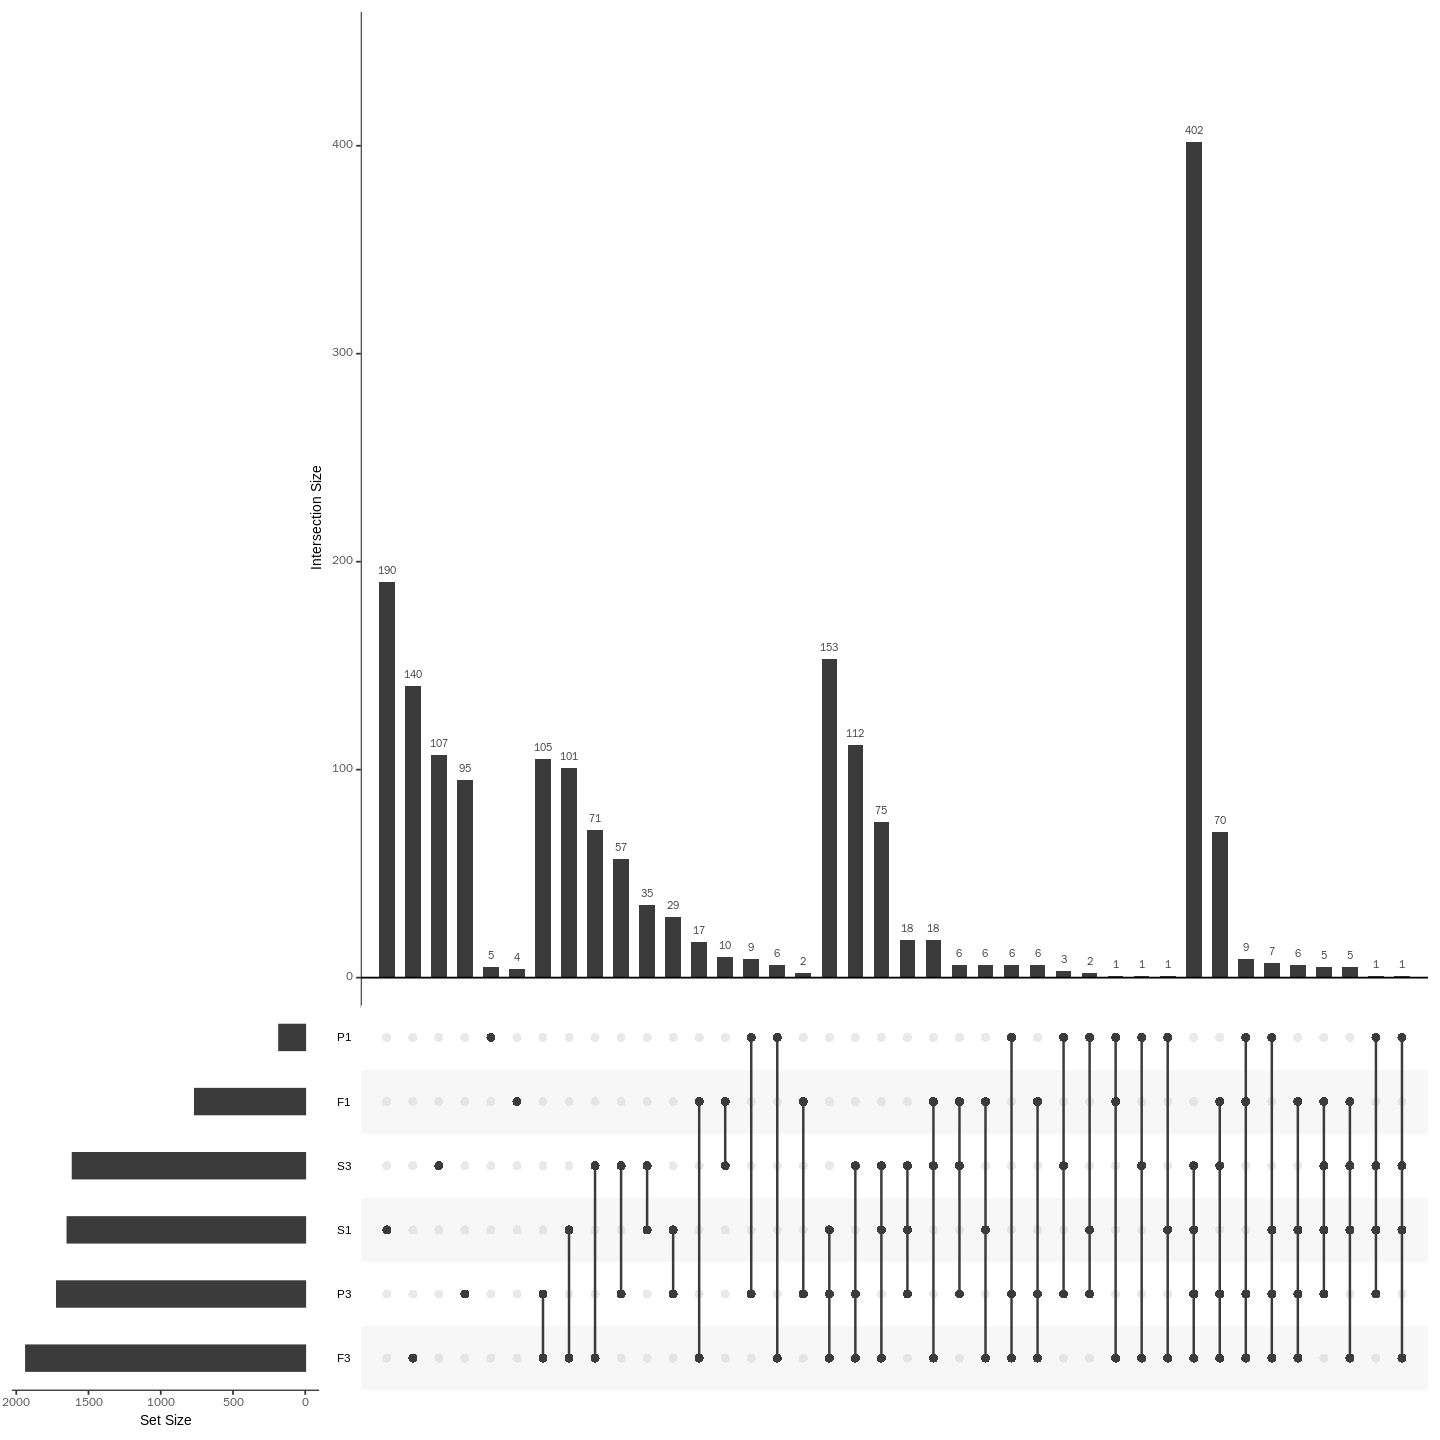

In [322]:
# 太复杂
# 6个无法绘制venn图
options(
repr.plot.width=12,
repr.plot.height=12
)
library(UpSetR)
# 使用fromList函数将列表转为二进制矩阵格式
protein_data <- UpSetR::fromList(plot_input)
head(protein_data)
upset(protein_data, sets = c("F1", "F3", "P1", "P3", "S1", "S3"))

In [315]:
plot_input_1 <- list(F=c(list_1[[1]][[1]]$`Protein`,list_1[[2]][[1]]$`Protein`),
     P=c(list_1[[3]][[1]]$`Protein`,list_1[[4]][[1]]$`Protein`),
     S=c(list_1[[5]][[1]]$`Protein`,list_1[[6]][[1]]$`Protein`))

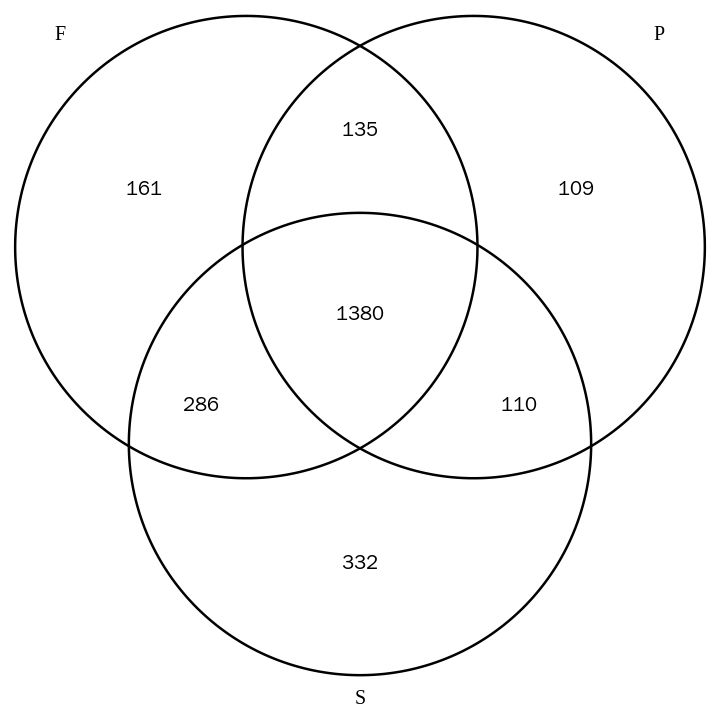

In [331]:
venn.plot <- venn.diagram(
  x = plot_input_1,
  category.names = names(plot_input_1),  # 确保类别名称与列表中的集合一致
  filename = NULL
)
options(
repr.plot.width=6,
repr.plot.height=6
)
grid::grid.draw(venn.plot)

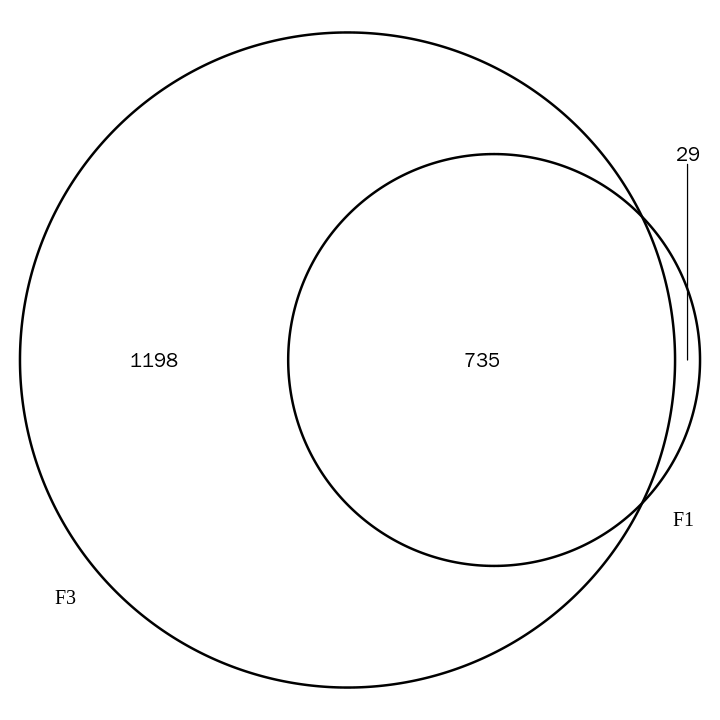

In [328]:
comparisons <- c("F1","F3")
options(
repr.plot.width=6,
repr.plot.height=6
)
venn.plot <- venn.diagram(
  x = plot_input[comparisons],
  category.names = names(plot_input[comparisons]),  # 确保类别名称与列表中的集合一致
  filename = NULL
)
grid::grid.draw(venn.plot)

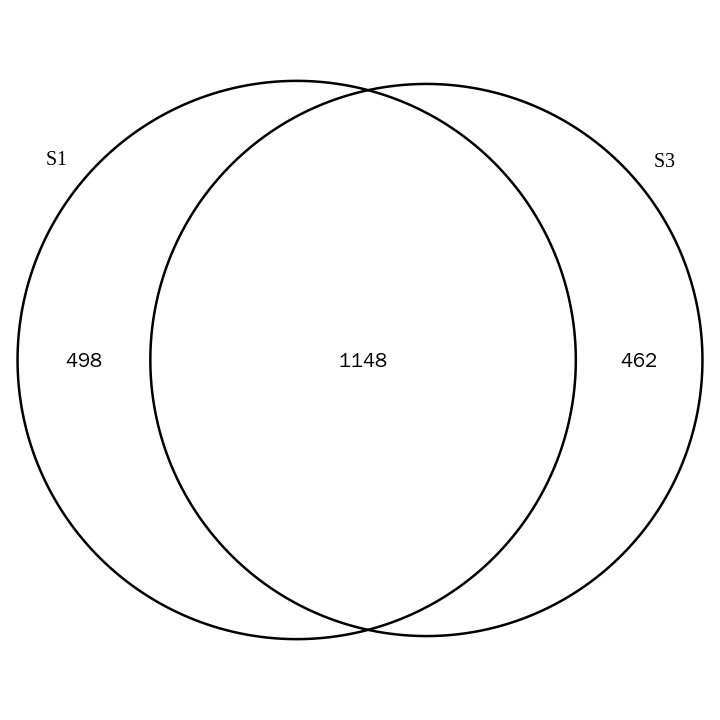

In [329]:
comparisons <- c("S1","S3")
options(
repr.plot.width=6,
repr.plot.height=6
)
venn.plot <- venn.diagram(
  x = plot_input[comparisons],
  category.names = names(plot_input[comparisons]),  # 确保类别名称与列表中的集合一致
  filename = NULL
)
grid::grid.draw(venn.plot)

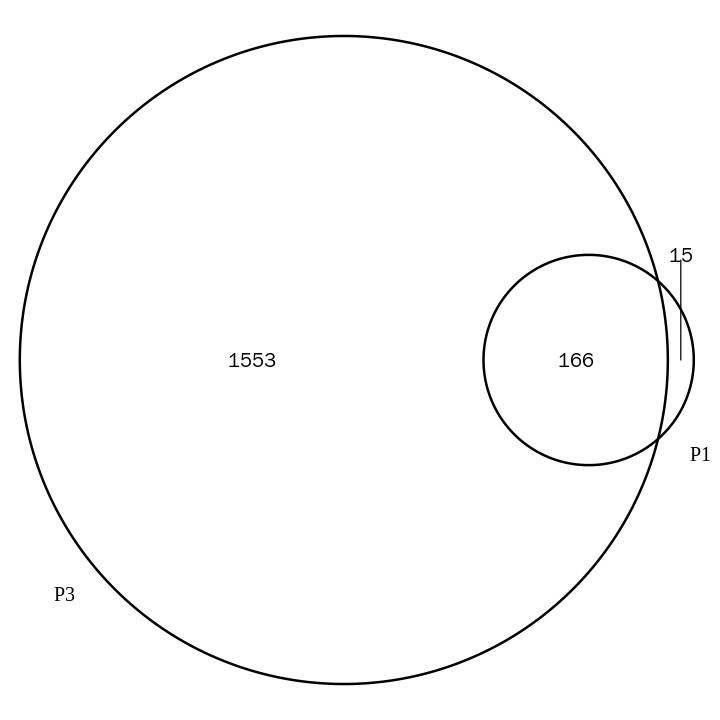

In [330]:
comparisons <- c("P1","P3")
options(
repr.plot.width=6,
repr.plot.height=6
)
venn.plot <- venn.diagram(
  x = plot_input[comparisons],
  category.names = names(plot_input[comparisons]),  # 确保类别名称与列表中的集合一致
  filename = NULL
)
grid::grid.draw(venn.plot)

# 交集 clean

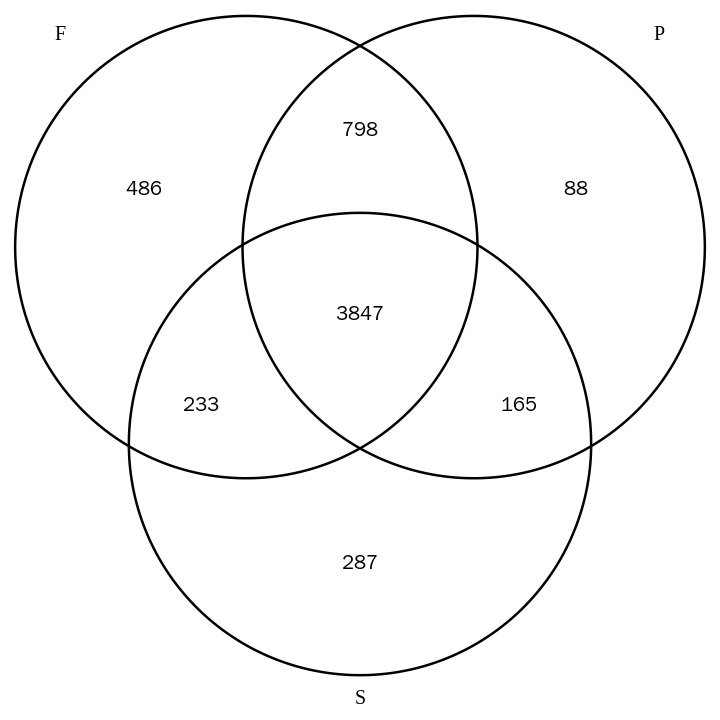

In [342]:
# 设置搜索的路径
search_path <- "./output/MS/Fragpipe_output/2024-11-01-03/"
# 使用list.files查找所有名为"protein.tsv"的文件
protein_files <- list.files(search_path, pattern = "^protein.tsv", full.names = TRUE,recursive = T)
lapply(protein_files,get_list) -> list_1

plot_input <- list(F2=list_1[[1]][[1]]$`Protein`,
     F4=list_1[[2]][[1]]$`Protein`,
     P2=list_1[[3]][[1]]$`Protein`,
     P4=list_1[[4]][[1]]$`Protein`,
     S2=list_1[[5]][[1]]$`Protein`,
     S4=list_1[[6]][[1]]$`Protein`)

plot_input_1 <- list(F=c(list_1[[1]][[1]]$`Protein`,list_1[[2]][[1]]$`Protein`),
     P=c(list_1[[3]][[1]]$`Protein`,list_1[[4]][[1]]$`Protein`),
     S=c(list_1[[5]][[1]]$`Protein`,list_1[[6]][[1]]$`Protein`))

comparisons_venn <- function(plot_input,comparisons){
venn.plot <- venn.diagram(
  x = plot_input[comparisons],
  category.names = names(plot_input[comparisons]),  # 确保类别名称与列表中的集合一致
  filename = NULL
)
options(
repr.plot.width=6,
repr.plot.height=6
)
grid::grid.draw(venn.plot)   
}


comparisons_venn(plot_input_1,c("F", "P","S"))

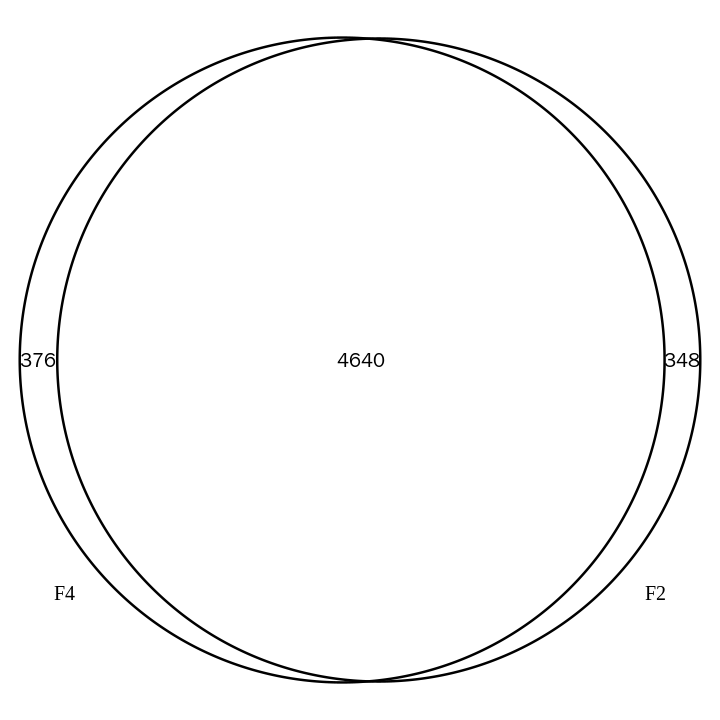

In [343]:
comparisons_venn(plot_input,c("F2", "F4"))

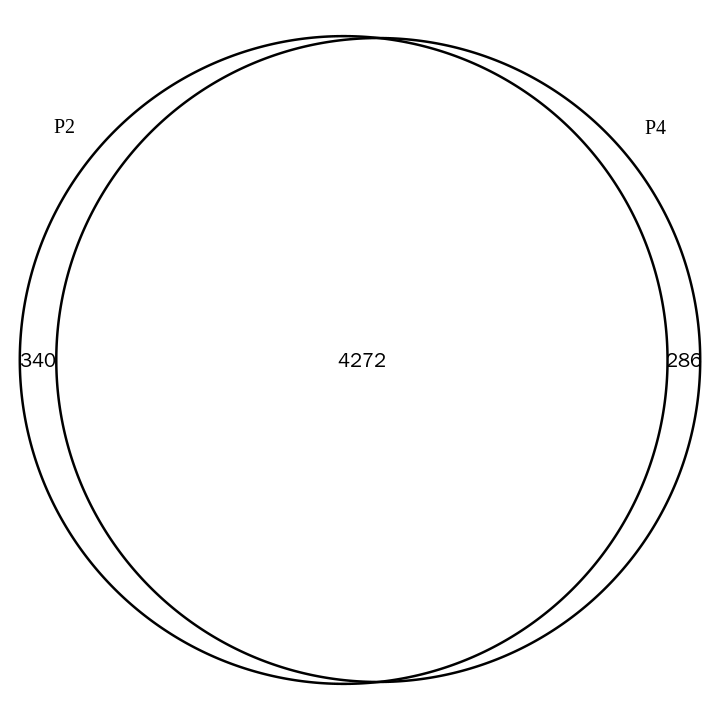

In [344]:
comparisons_venn(plot_input,c("P2", "P4"))

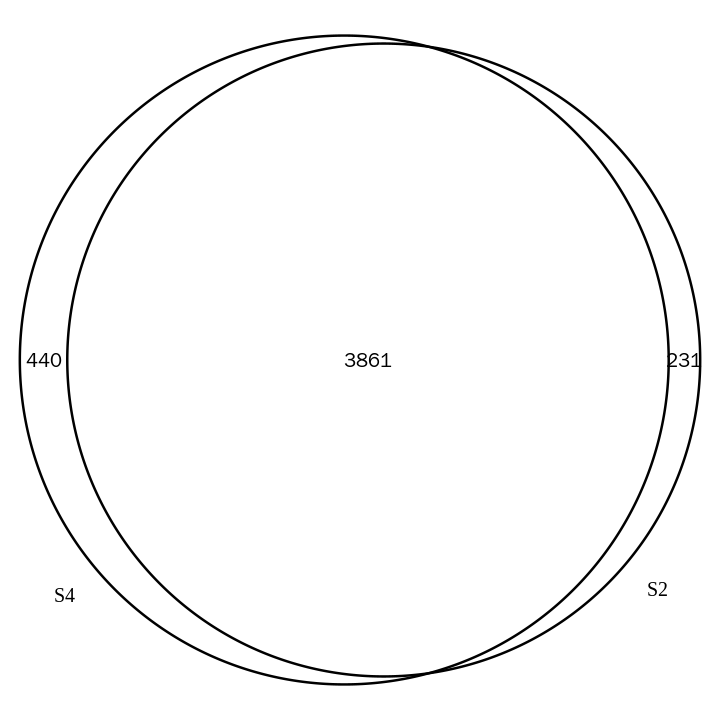

In [345]:
comparisons_venn(plot_input,c("S2", "S4"))

# 突出问题

In [358]:
df <- fread("./output/MS//Fragpipe_output//2024-10-31-4/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561/protein.tsv")

In [364]:
nrow(df)
df %>% filter(Organism=="Mus musculus" | Organism=="") -> df_fil_spe
nrow(df_fil_spe)
df_fil_spe[!grepl("^rev",df_fil_spe$Protein),] -> df_fil_spe_decoy
nrow(df_fil_spe_decoy)
df_fil_spe_decoy  %>% filter(`Unique Peptides`>0) -> df_unique
nrow(df_unique)

[1] 750

[1] 741

[1] 741

[1] 553

In [362]:
head(df_unique)

Protein,Protein ID,Entry Name,Gene,Length,Organism,Protein Description,Protein Existence,Coverage,Protein Probability,⋯,Razor Peptides,Total Spectral Count,Unique Spectral Count,Razor Spectral Count,Total Intensity,Unique Intensity,Razor Intensity,Razor Assigned Modifications,Razor Observed Modifications,Indistinguishable Proteins
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
sp|A2AQ07|TBB1_MOUSE,A2AQ07,TBB1_MOUSE,Tubb1,451,Mus musculus,Tubulin beta-1 chain,1:Experimental evidence at protein level,6.43,1,⋯,1,7,0,0,298661.40,15098.47,15098.47,,NA,
sp|A2AS89|GDAH_MOUSE,A2AS89,GDAH_MOUSE,Agmat,358,Mus musculus,"Guanidino acid hydrolase, mitochondrial",1:Experimental evidence at protein level,8.38,1,⋯,1,1,1,1,11292.71,11292.71,11292.71,,NA,
sp|A2RT62|FXL16_MOUSE,A2RT62,FXL16_MOUSE,Fbxl16,479,Mus musculus,F-box/LRR-repeat protein 16,1:Experimental evidence at protein level,7.10,1,⋯,1,1,1,1,15271.95,15271.95,15271.95,8C(57.0215),NA,
sp|B2RSH2|GNAI1_MOUSE,B2RSH2,GNAI1_MOUSE,Gnai1,354,Mus musculus,Guanine nucleotide-binding protein G(i) subunit alpha-1,1:Experimental evidence at protein level,4.24,1,⋯,3,1,0,1,37934.87,11719.18,35131.69,,NA,
sp|B9EKR1|PTPRZ_MOUSE,B9EKR1,PTPRZ_MOUSE,Ptprz1,2312,Mus musculus,Receptor-type tyrosine-protein phosphatase zeta,1:Experimental evidence at protein level,0.69,1,⋯,1,1,1,1,35144.22,35144.22,35144.22,,NA,
sp|D3YVF0|AKAP5_MOUSE,D3YVF0,AKAP5_MOUSE,Akap5,745,Mus musculus,A-kinase anchor protein 5,1:Experimental evidence at protein level,2.82,1,⋯,3,1,1,1,52932.33,52932.33,52932.33,,NA,


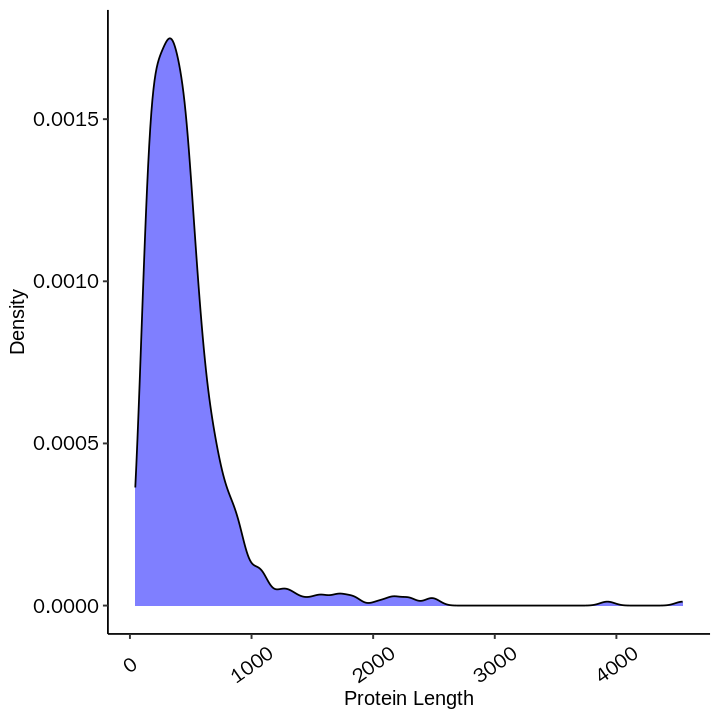

In [366]:
ggplot(df_unique, aes(x=Length)) +
  geom_density(fill="blue", alpha=0.5) +
  xlab("Protein Length") +
  ylab("Density")+theme_pubr()+
theme(axis.text.x = element_text(angle=35,vjust = 0.5,hjust = 0.5))

Warning message:
“Removed 34 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


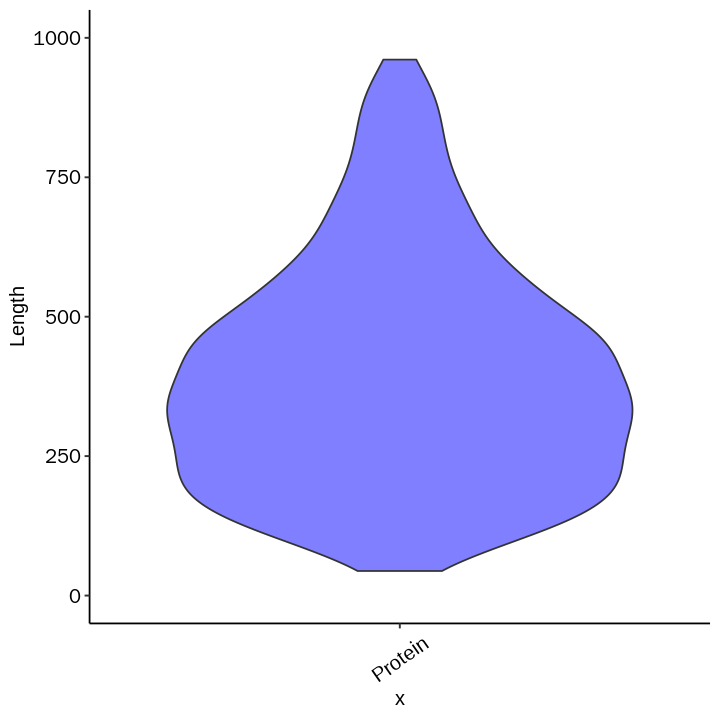

In [377]:
ggplot(df_unique, aes(x="Protein",y=Length)) +
  geom_violin(fill="blue", alpha=0.5) +theme_pubr()+
theme(axis.text.x = element_text(angle=35,vjust = 0.5,hjust = 0.5))+
scale_y_continuous(limits=c(0,1000))

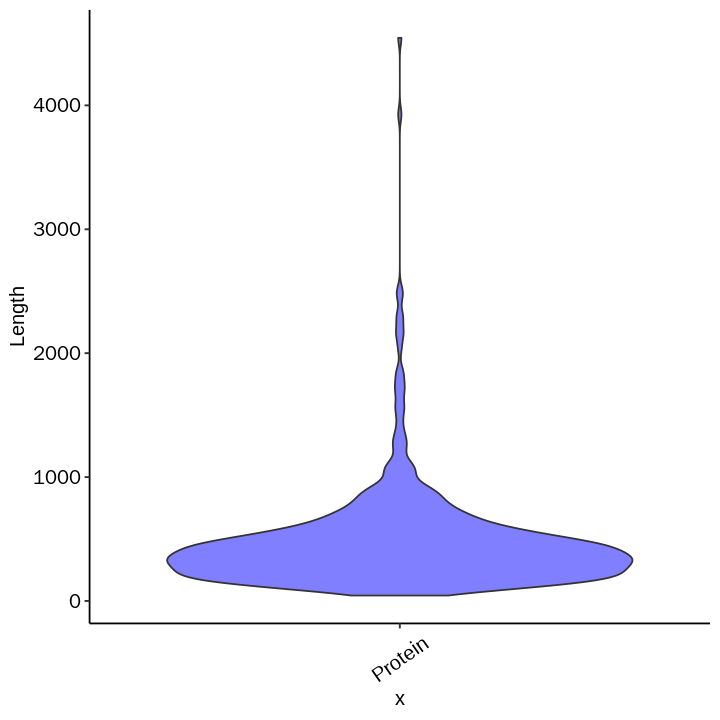

In [378]:
ggplot(df_unique, aes(x="Protein",y=Length)) +
  geom_violin(fill="blue", alpha=0.5) +theme_pubr()+
theme(axis.text.x = element_text(angle=35,vjust = 0.5,hjust = 0.5))

In [383]:
peptides <- fread("./output/MS//Fragpipe_output//2024-10-31-4/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2_51_1_3561/peptide.tsv")

In [384]:
head(peptides)
peptides$Length <- peptides$End - peptides$Start + 1

Peptide,Prev AA,Next AA,Start,End,Peptide Length,Charges,Probability,Spectral Count,Intensity,Match Type,Assigned Modifications,Observed Modifications,Protein,Protein ID,Entry Name,Gene,Protein Description,Mapped Genes,Mapped Proteins
<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAAAATAVGPGAGSAGVAGPGGAGPCATVSVFPGAR,M,L,2,37,36,3,NA,0,5009.460,MBR,"26C(57.0215),N-term(42.0106)",NA,sp|Q9WVG6-2|CARM1_MOUSE,Q9WVG6-2,CARM1_MOUSE,Carm1,Isoform 2 of Histone-arginine methyltransferase CARM1,,sp|Q9WVG6|CARM1_MOUSE
AAAAVASAASSCRPLGSGTAPNPTAAAPASSPAPGPGPVGK,R,G,6,46,41,"3,4",1,3,32170.420,MS/MS,12C(57.0215),NA,sp|P58404-2|STRN4_MOUSE,P58404-2,STRN4_MOUSE,Strn4,Isoform 2 of Striatin-4,,sp|P58404|STRN4_MOUSE
AAADIARQVGEDCR,M,T,2,15,14,2,NA,0,4365.531,MBR,"13C(57.0215),N-term(42.0106)",NA,sp|Q9R1T4-2|SEPT6_MOUSE,Q9R1T4-2,SEPT6_MOUSE,Septin6,Isoform I of Septin-6,,"sp|Q9R1T4-3|SEPT6_MOUSE, sp|Q9R1T4|SEPT6_MOUSE"
AAAFVTSPPINPDPTTADHLTSLLSSGDLQVTGSAHCTFTTAQK,K,A,298,341,44,4,1,2,63937.906,MS/MS,37C(57.0215),NA,sp|O35098|DPYL4_MOUSE,O35098,DPYL4_MOUSE,Dpysl4,Dihydropyrimidinase-related protein 4,,sp|O35098-2|DPYL4_MOUSE
AAAFVTSPPLSPDPTTPDFLNSLLSCGDLQVTGSAHCTFNTAQK,K,A,298,341,44,"3,4",1,17,840416.300,MS/MS,"26C(57.0215),37C(57.0215)",NA,sp|O08553|DPYL2_MOUSE,O08553,DPYL2_MOUSE,Dpysl2,Dihydropyrimidinase-related protein 2,,
AAAFVTSPPLSPDPTTPDYINSLLASGDLQLSGSAHCTFSTAQK,K,A,298,341,44,"3,4",1,3,19153.025,MS/MS,37C(57.0215),NA,sp|Q62188|DPYL3_MOUSE,Q62188,DPYL3_MOUSE,Dpysl3,Dihydropyrimidinase-related protein 3,,


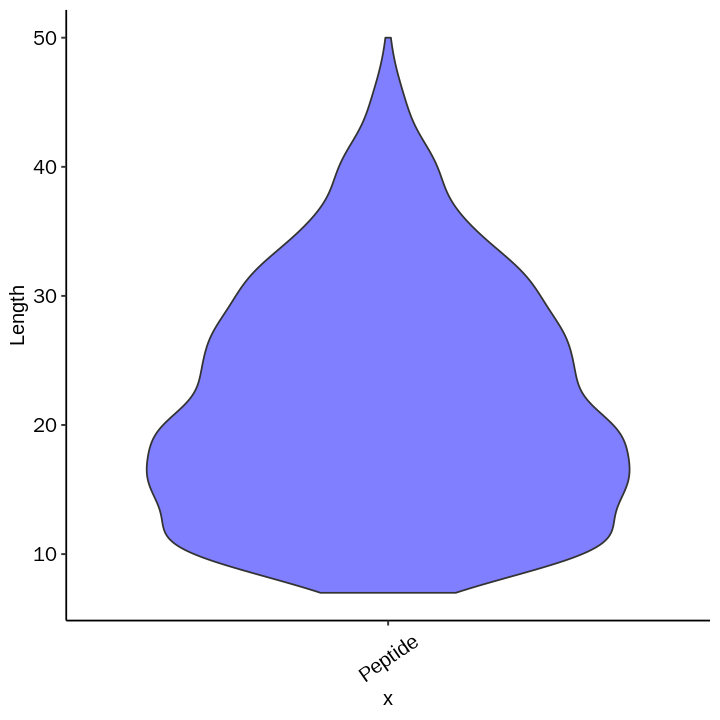

In [386]:
ggplot(peptides, aes(x="Peptide",y=Length)) +
  geom_violin(fill="blue", alpha=0.5) +theme_pubr()+
theme(axis.text.x = element_text(angle=35,vjust = 0.5,hjust = 0.5))

In [387]:
range(peptides$`Peptide Length`)

[1]  7 50

# 对MS数据进行统计

In [1]:
library("mzR")
# library("MSnbase")
library("Spectra")
library("ProtGenerics")
library("msdata")
library("PSMatch")

载入需要的程辑包：Rcpp

Warning message:
“程辑包‘Rcpp’是用R版本4.3.2 来建造的”
载入需要的程辑包：S4Vectors

载入需要的程辑包：stats4

载入需要的程辑包：BiocGenerics


载入程辑包：‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



载入程辑包：‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


载入需要的程辑包：BiocParallel

载入需要的程辑包：ProtGenerics


载入程辑包：‘ProtGenerics’


The following object is masked from ‘package:stats’:

    smooth




In [437]:
f <- "/rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561_uncalibrated.mzML"

In [433]:
library("Spectra")
spectra <- Spectra(f)

In [434]:
head(spectra)
length(spectra)
msLevel(spectra) %>% length()
rtime(spectra) %>% length()
precursorIntensity(spectra) %>% length()
precursorMz(spectra) %>% head()
rtime(spectra) %>% head()
# plotSpectra(spectra)
intensity(spectra) %>% head()
mz(spectra) %>% head()

MSn data (Spectra) with 6 spectra in a MsBackendMzR backend:
    msLevel     rtime scanIndex
  <integer> <numeric> <integer>
1         2   8.16005         1
2         2  10.96497         2
3         2  10.96497         3
4         2  12.64812         4
5         2  14.41466         5
6         2  17.50703         6
 ... 33 more variables/columns.

file(s):
CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561_uncalibrated.mzML

[1] 38051

[1] 38051

[1] 38051

[1] 38051

[1]  924.0139 1221.9893  922.0095 1221.9904    0.0000  622.0274

[1]  8.160045 10.964974 10.964974 12.648118 14.414655 17.507029

NumericList of length 6
[[1]] 10 10 10 10 10 10 10 10 10 21 115 10 ... 35 10 43 10 33 10 10 10 10 10 10
[[2]] 66 34 51 10 55 28 59 10 72 10 14 265 ... 23 24 10 61 22 20 43 23 10 13 10
[[3]] 10 104 64 29 104 64 58 54 63 48 75 ... 11 26 18 31 44 35 12 35 23 27 52
[[4]] 10 10 10 10 10 10 10 11 10 10 10 10 ... 37 28 25 10 17 12 10 10 10 14 10
[[5]] 10 10 10 10 87 10 86 69 64 99 89 55 ... 47 24 81 10 10 28 10 10 10 10 10
[[6]] 10 10 10 68 60 60 94 86 10 74 61 ... 62 25 145 12 23 11 11 10 10 10 10

NumericList of length 6
[[1]] 108.087745666504 111.301788330078 ... 1309.70458984375 1595.24340820312
[[2]] 229.921569824219 250.907516479492 ... 1231.38842773438 1254.71813964844
[[3]] 95.8526458740234 228.914459228516 ... 939.481750488281 996.504028320312
[[4]] 138.21272277832 196.397827148438 ... 1431.91125488281 1550.7939453125
[[5]] 96.6555252075195 111.295043945312 ... 1340.42407226562 1547.52270507812
[[6]] 150.884918212891 158.381423950195 ... 1508.76000976562 1525.044921875

In [435]:
# 统计 MS1 和 MS2 谱图数量
ms1_count <- sum(msLevel(spectra) == 1)
ms2_count <- sum(msLevel(spectra) == 2)

cat("MS1 count:", ms1_count, "\n")
cat("MS2 count:", ms2_count, "\n")

MS1 count: 0 
MS2 count: 38051 


In [438]:
library("mzR")
ms_file <- openMSfile(f)

# 获取谱图信息
header_info <- header(ms_file)

# 分别统计 MS1 和 MS2
ms1_count <- sum(header_info$msLevel == 1)
ms2_count <- sum(header_info$msLevel == 2)

cat("MS1 count:", ms1_count, "\n")
cat("MS2 count:", ms2_count, "\n")

MS1 count: 0 
MS2 count: 38051 


## 新的mzML

In [428]:
f <- "/rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561.mzML"
spectra <- Spectra(f)

ERROR: Error: BiocParallel errors
  1 remote errors, element index: 1
  0 unevaluated and other errors
  first remote error:
Error: Can not open file /rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561.mzML! Original error was: Error in eval(expr, envir, enclos): [SAXParser::ParserWrangler::elementEnd()] Illegal end tag "binaryDataArray" at offset 13168146598.




In [ ]:
# 统计 MS1 和 MS2 谱图数量
ms1_count <- sum(msLevel(spectra) == 1)
ms2_count <- sum(msLevel(spectra) == 2)

cat("MS1 count:", ms1_count, "\n")
cat("MS2 count:", ms2_count, "\n")

In [429]:
ms_file <- openMSfile(f)

# 获取谱图信息
header_info <- header(ms_file)

# 分别统计 MS1 和 MS2
ms1_count <- sum(header_info$msLevel == 1)
ms2_count <- sum(header_info$msLevel == 2)

cat("MS1 count:", ms1_count, "\n")
cat("MS2 count:", ms2_count, "\n")

ERROR: Error: Can not open file /rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561.mzML! Original error was: Error in eval(expr, envir, enclos): [SAXParser::ParserWrangler::elementEnd()] Illegal end tag "binaryDataArray" at offset 13168146598.



## mgf

In [430]:
f <- "/rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561.mgf"
spectra <- Spectra(f)

ERROR: Error: BiocParallel errors
  1 remote errors, element index: 1
  0 unevaluated and other errors
  first remote error:
Error in .mzRBackendFromContent(x): Could not determine file type for /rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561.mgf



In [431]:
ms_file <- openMSfile(f)

# 获取谱图信息
header_info <- header(ms_file)

# 分别统计 MS1 和 MS2
ms1_count <- sum(header_info$msLevel == 1)
ms2_count <- sum(header_info$msLevel == 2)

cat("MS1 count:", ms1_count, "\n")
cat("MS2 count:", ms2_count, "\n")

ERROR: Error in .mzRBackendFromContent(x): Could not determine file type for /rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561.mgf


## 自定义脚本

In [439]:
from lxml import etree

# 读取文件
f <- "/rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F1_Slot2-51_1_3561.mzML"
tree = etree.parse(f)
root = tree.getroot()

# 定义命名空间
ns = {"ns": "http://psi.hupo.org/ms/mzml"}

# 遍历光谱列表
spectra = root.xpath("//ns:spectrum", namespaces=ns)
ms1_count = sum(1 for spectrum in spectra if spectrum.xpath(".//ns:cvParam[@name='ms level'][@value='1']", namespaces=ns))
ms2_count = sum(1 for spectrum in spectra if spectrum.xpath(".//ns:cvParam[@name='ms level'][@value='2']", namespaces=ns))

print(f"MS1数量: {ms1_count}, MS2数量: {ms2_count}")

ERROR: Error in parse(text = x, srcfile = src): <text>:1:6: unexpected symbol
1: from lxml
         ^


# 20250110

In [3]:
mzml = "/rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/converted_files/F2_bruker.mzML"

In [4]:
library("Spectra")
spectra <- Spectra(mzml)
# 统计 MS1 和 MS2 谱图数量
ms1_count <- sum(msLevel(spectra) == 1)
ms2_count <- sum(msLevel(spectra) == 2)

cat("MS1 count:", ms1_count, "\n")
cat("MS2 count:", ms2_count, "\n")

MS1 count: 5007 
MS2 count: 30357 


In [5]:
mzml_1="/rd1/user/lit/project/sORFs/raw_data/MS/Guomics_SP_MSdata/CAD20241022licq_BSEP_PreExp_DDA_60min/CAD20241022licq_BSEP_PreExp_DDA_60min_F2_Slot2-52_1_3562_uncalibrated.mzML"

In [6]:
library("Spectra")
spectra <- Spectra(mzml_1)
# 统计 MS1 和 MS2 谱图数量
ms1_count <- sum(msLevel(spectra) == 1)
ms2_count <- sum(msLevel(spectra) == 2)

cat("MS1 count:", ms1_count, "\n")
cat("MS2 count:", ms2_count, "\n")

MS1 count: 0 
MS2 count: 176271 
